In [23]:
import pandas as pd
df=pd.read_csv('cardekho_dataset.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [24]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [25]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [26]:
df.duplicated().sum()

np.int64(167)

In [27]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

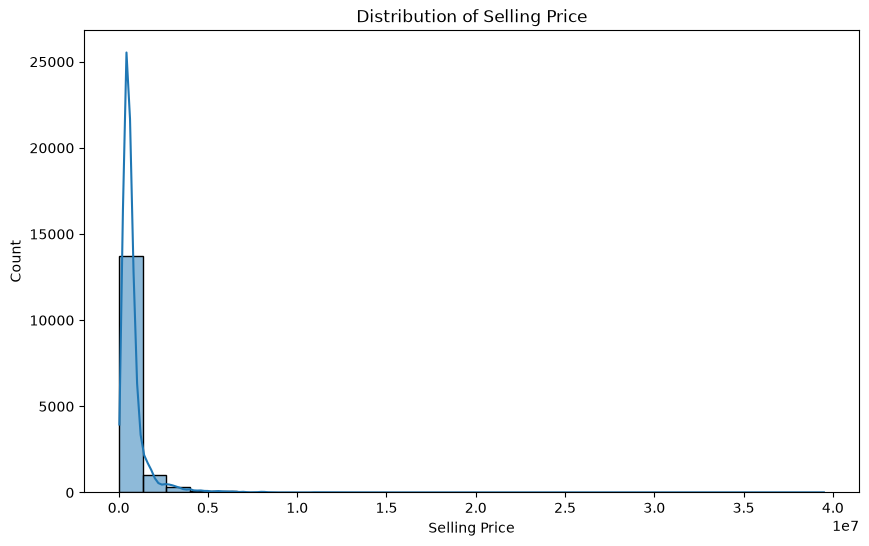

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.histplot(df['selling_price'], bins=30, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.show()

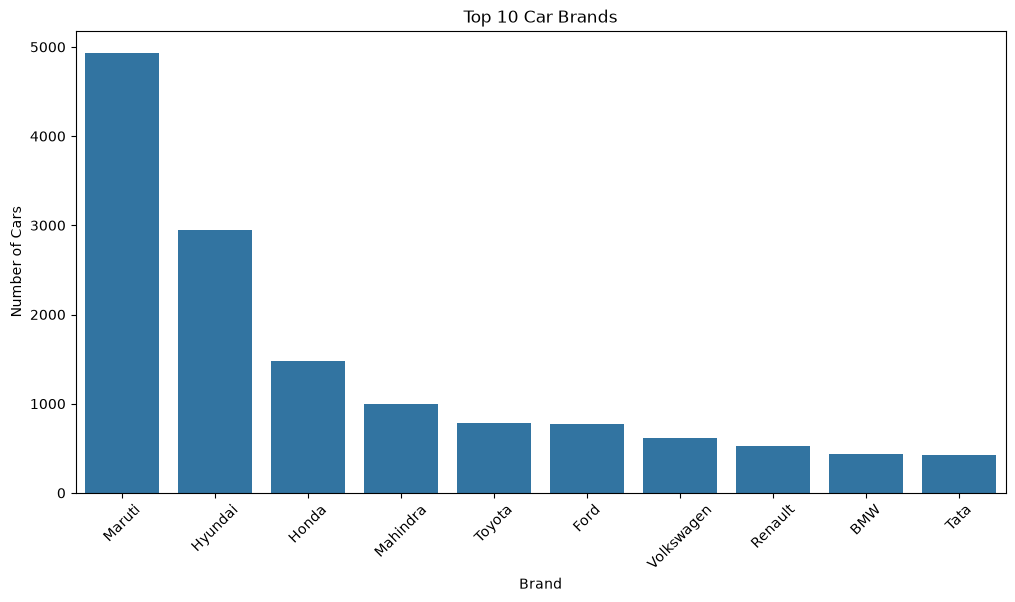

In [29]:
plt.figure(figsize=(12,6))

top_brands = df['brand'].value_counts().head(10)

sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.title("Top 10 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

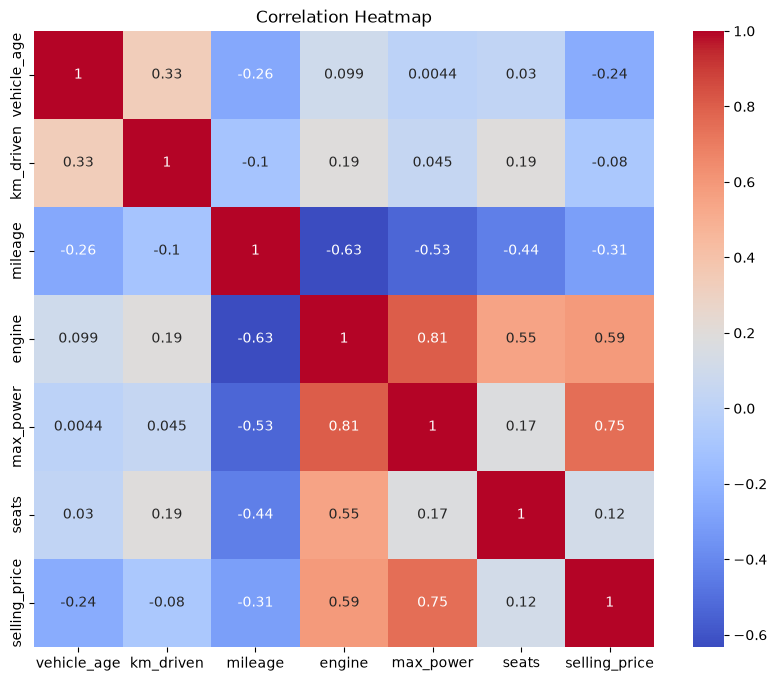

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [31]:
x=df.drop(columns=['selling_price'])
y=df['selling_price']

In [32]:
categorical_columns=x.select_dtypes(include="object").columns
print(categorical_columns)

Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='str')


/tmp/ipykernel_31268/3778550347.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=x.select_dtypes(include="object").columns


In [33]:
from sklearn.preprocessing import OrdinalEncoder
encoder=OrdinalEncoder()
x[categorical_columns] = encoder.fit_transform(x[categorical_columns])

In [34]:
x.info()

<class 'pandas.DataFrame'>
Index: 15244 entries, 0 to 15410
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15244 non-null  float64
 1   brand              15244 non-null  float64
 2   model              15244 non-null  float64
 3   vehicle_age        15244 non-null  int64  
 4   km_driven          15244 non-null  int64  
 5   seller_type        15244 non-null  float64
 6   fuel_type          15244 non-null  float64
 7   transmission_type  15244 non-null  float64
 8   mileage            15244 non-null  float64
 9   engine             15244 non-null  int64  
 10  max_power          15244 non-null  float64
 11  seats              15244 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 1.5 MB


In [35]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
from sklearn.linear_model import LinearRegression
LR_model=LinearRegression()
LR_model.fit(x_train,y_train)
y_pred=LR_model.predict(x_test)
print("Car Price Prediction:", y_pred)

Car Price Prediction: [ 519024.65920165  720143.76340211  728933.23852489 ... 1642490.49248833
  344798.2676596  3478890.1051533 ]


In [37]:
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error,r2_score
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))

Mean Squared Error: 197139466175.87762
R2 Score: 0.6757685615582383
Mean Absolute Error: 253052.55606493063


In [38]:
from sklearn.tree import DecisionTreeRegressor
DT_model=DecisionTreeRegressor()
DT_model.fit(x_train,y_train)
y_DT_pred=DT_model.predict(x_test)
print("Car Price Prediction:", y_DT_pred)

Car Price Prediction: [ 520000.  360000.  822500. ... 1775000.  235000. 3900000.]


In [39]:
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error,r2_score
print("Mean Squared Error:",mean_squared_error(y_test,y_DT_pred))
print("R2 Score:",r2_score(y_test,y_DT_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_DT_pred))

Mean Squared Error: 112483605208.99385
R2 Score: 0.8150004064356651
Mean Absolute Error: 128910.2765934186


In [40]:
from sklearn.ensemble import RandomForestRegressor
RF_model=RandomForestRegressor()
RF_model.fit(x_train,y_train)
y_RF_pred=RF_model.predict(x_test)
print("Car Price Prediction:", y_RF_pred)

Car Price Prediction: [ 569044.16666667  343635.83333333  804559.16666667 ... 1590310.
  229170.         4461680.        ]


In [41]:
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error,r2_score
print("Mean Squared Error:",mean_squared_error(y_test,y_RF_pred))
print("R2 Score:",r2_score(y_test,y_RF_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_RF_pred))

Mean Squared Error: 99070536629.23172
R2 Score: 0.8370606189537124
Mean Absolute Error: 102975.94562017554


In [42]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    random_state=42
)
xgb_model.fit(x_train, y_train)
y_xgb_pred = xgb_model.predict(x_test)
print("Car Price Prediction:", y_xgb_pred)

Car Price Prediction: [6.0626625e+05 3.6007362e+05 7.2284656e+05 ... 1.5172448e+06 2.4359980e+05
 4.1847218e+06]


In [43]:
from sklearn.metrics import accuracy_score,mean_absolute_error,mean_squared_error,r2_score
print("Mean Squared Error:",mean_squared_error(y_test,y_xgb_pred))
print("R2 Score:",r2_score(y_test,y_xgb_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test,y_xgb_pred))

Mean Squared Error: 37041291264.0
R2 Score: 0.9390789270401001
Mean Absolute Error: 92296.28125


In [44]:
import os
import pickle
os.makedirs("model", exist_ok=True)
with open("model/car_price_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

with open("model/encoder.pkl", "wb") as file:
    pickle.dump(encoder, file)

print("Model and encoder saved successfully!")

Model and encoder saved successfully!
